In [20]:
%pip install -q pandas numpy matplotlib scikit-learn kagglehub


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
# Week 9 - Gradient Boosting

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import kagglehub

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

print(f"scikit-learn version: {sklearn.__version__}")
print("All imports successful.")

scikit-learn version: 1.9.0
All imports successful.


In [22]:
# 1. Data Loading and Cleaning

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")

print(f"Raw shape: {df.shape}")

# Remove duplicate records
df = df.drop_duplicates().copy()

# Median imputation for employment length
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

# Grade-matched median imputation for interest rate
df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df.groupby("loan_grade")["loan_int_rate"].transform("median")
)

# Remove logically impossible observations
df = df[df["person_emp_length"] <= df["person_age"]]
df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 60]

print(f"Clean shape: {df.shape}")
print(f"Default rate: {df['loan_status'].mean() * 100:.2f}%")
print("\nMissing values:")
print(df.isna().sum())

Raw shape: (32581, 12)
Clean shape: (32409, 12)
Default rate: 21.87%

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [23]:
# 2. Classification Target and Feature Preparation

numeric_features = [
    "person_income",
    "person_age",
    "person_emp_length",
    "loan_amnt",
    "loan_percent_income",
    "loan_int_rate"
]

categorical_features = [
    "loan_intent",
    "loan_grade",
    "person_home_ownership",
    "cb_person_default_on_file"
]

X = df[numeric_features + categorical_features].copy()
y = df["loan_status"].copy()

# Keep complete modeling rows
complete_mask = X.notna().all(axis=1)
X = X.loc[complete_mask]
y = y.loc[complete_mask]

# Preserve the same stratified split used in the previous classification notebooks
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Gradient-boosted trees do not require scaling.
# Categorical variables are one-hot encoded into numeric indicators.
encoder = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

categorical_names = (
    encoder.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

feature_names = numeric_features + categorical_names

# Use float32 to reduce memory consumption
X_train_enc = np.asarray(X_train_enc, dtype=np.float32)
X_test_enc = np.asarray(X_test_enc, dtype=np.float32)

# GradientBoostingClassifier does not use a class_weight argument.
# Balanced sample weights give greater influence to the minority default class.
train_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print(f"Encoded features: {len(feature_names)}")
print(f"Training observations: {len(y_train):,}")
print(f"Testing observations: {len(y_test):,}")
print(f"Training default rate: {y_train.mean() * 100:.2f}%")
print(f"Testing default rate: {y_test.mean() * 100:.2f}%")

Encoded features: 25
Training observations: 25,927
Testing observations: 6,482
Training default rate: 21.87%
Testing default rate: 21.88%


In [24]:
# 3. Reusable Evaluation Function

def evaluate_classifier(
    model_name,
    model,
    X_eval,
    y_eval,
    threshold=0.50
):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, predictions),
        "ROC AUC": roc_auc_score(y_eval, probabilities),
        "Average Precision": average_precision_score(y_eval, probabilities),
        "Default Precision": precision_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "Default Recall": recall_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "Default F1": f1_score(
            y_eval,
            predictions,
            zero_division=0
        )
    }

    return results, probabilities, predictions

In [25]:
# 4. Baseline Gradient Boosting Classifier

baseline_gb = GradientBoostingClassifier(
    random_state=42
)

baseline_gb.fit(
    X_train_enc,
    y_train,
    sample_weight=train_weights
)

baseline_results, baseline_probabilities, baseline_predictions = (
    evaluate_classifier(
        model_name="Baseline Gradient Boosting",
        model=baseline_gb,
        X_eval=X_test_enc,
        y_eval=y_test
    )
)

print("Baseline Gradient Boosting")
print("-" * 40)

for metric, value in baseline_results.items():
    if metric not in ["Model", "Threshold"]:
        print(f"{metric:<22}: {value:.4f}")

print("\nClassification Report")
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=["Repaid", "Default"]
    )
)

Baseline Gradient Boosting
----------------------------------------
Accuracy              : 0.8854
Balanced Accuracy     : 0.8530
ROC AUC               : 0.9323
Average Precision     : 0.8779
Default Precision     : 0.7135
Default Recall        : 0.7955
Default F1            : 0.7523

Classification Report
              precision    recall  f1-score   support

      Repaid       0.94      0.91      0.93      5064
     Default       0.71      0.80      0.75      1418

    accuracy                           0.89      6482
   macro avg       0.83      0.85      0.84      6482
weighted avg       0.89      0.89      0.89      6482



 Learning Rate  Number of Trees  CV AUC Mean  CV AUC Std
          0.10              100       0.9173      0.0031
          0.05              200       0.9170      0.0027
          0.03              300       0.9156      0.0027
          0.02              400       0.9140      0.0025


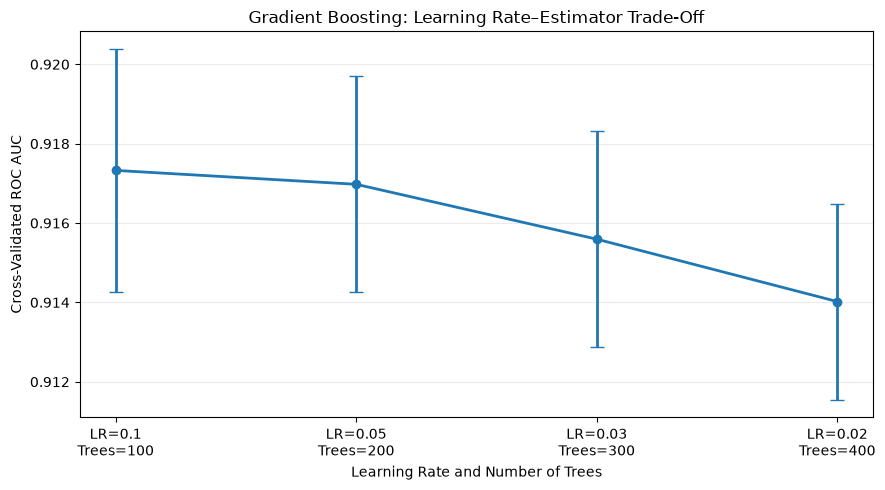


Best learning-rate experiment: learning_rate=0.1, n_estimators=100, CV AUC=0.9173


In [26]:
# 5. Learning Rate and Number-of-Trees Experiment

def weighted_cross_validated_auc(
    model,
    X_data,
    y_data,
    n_splits=4
):
    y_array = np.asarray(y_data)

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    fold_scores = []

    for fit_indices, validation_indices in cv.split(X_data, y_array):
        fold_model = clone(model)

        fold_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_array[fit_indices]
        )

        fold_model.fit(
            X_data[fit_indices],
            y_array[fit_indices],
            sample_weight=fold_weights
        )

        validation_probabilities = fold_model.predict_proba(
            X_data[validation_indices]
        )[:, 1]

        fold_auc = roc_auc_score(
            y_array[validation_indices],
            validation_probabilities
        )

        fold_scores.append(fold_auc)

    return np.mean(fold_scores), np.std(fold_scores)


learning_rate_settings = [
    {"learning_rate": 0.10, "n_estimators": 100},
    {"learning_rate": 0.05, "n_estimators": 200},
    {"learning_rate": 0.03, "n_estimators": 300},
    {"learning_rate": 0.02, "n_estimators": 400}
]

learning_rate_results = []

for setting in learning_rate_settings:
    model = GradientBoostingClassifier(
        learning_rate=setting["learning_rate"],
        n_estimators=setting["n_estimators"],
        max_depth=2,
        min_samples_leaf=5,
        subsample=0.85,
        random_state=42
    )

    mean_auc, std_auc = weighted_cross_validated_auc(
        model=model,
        X_data=X_train_enc,
        y_data=y_train,
        n_splits=4
    )

    learning_rate_results.append({
        "Learning Rate": setting["learning_rate"],
        "Number of Trees": setting["n_estimators"],
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc
    })

learning_rate_df = pd.DataFrame(learning_rate_results)

print(learning_rate_df.round(4).to_string(index=False))

labels = [
    f"LR={row['Learning Rate']}\nTrees={int(row['Number of Trees'])}"
    for _, row in learning_rate_df.iterrows()
]

plt.figure(figsize=(9, 5))
plt.errorbar(
    labels,
    learning_rate_df["CV AUC Mean"],
    yerr=learning_rate_df["CV AUC Std"],
    marker="o",
    capsize=5,
    linewidth=2
)
plt.xlabel("Learning Rate and Number of Trees")
plt.ylabel("Cross-Validated ROC AUC")
plt.title("Gradient Boosting: Learning Rate–Estimator Trade-Off")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

best_experiment = learning_rate_df.loc[
    learning_rate_df["CV AUC Mean"].idxmax()
]

print(
    "\nBest learning-rate experiment:",
    f"learning_rate={best_experiment['Learning Rate']},",
    f"n_estimators={int(best_experiment['Number of Trees'])},",
    f"CV AUC={best_experiment['CV AUC Mean']:.4f}"
)

In [27]:
# 6. Hyperparameter Tuning with Stratified Cross-Validation

parameter_distributions = {
    "n_estimators": [100, 150, 200, 250, 300, 400],
    "learning_rate": [0.02, 0.03, 0.05, 0.075, 0.10],
    "max_depth": [1, 2, 3, 4],
    "min_samples_leaf": [3, 5, 10, 20],
    "subsample": [0.70, 0.85, 1.00],
    "max_features": [None, "sqrt", 0.70]
}

base_search_model = GradientBoostingClassifier(
    random_state=42
)

stratified_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

gradient_search = RandomizedSearchCV(
    estimator=base_search_model,
    param_distributions=parameter_distributions,
    n_iter=18,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    refit="roc_auc",
    cv=stratified_cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

gradient_search.fit(
    X_train_enc,
    y_train,
    sample_weight=train_weights
)

print("\nBest Parameters")
print(gradient_search.best_params_)

print(f"\nBest Cross-Validated AUC: {gradient_search.best_score_:.4f}")

search_results = pd.DataFrame(gradient_search.cv_results_)

search_summary = search_results[
    [
        "rank_test_roc_auc",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_test_average_precision",
        "mean_train_roc_auc",
        "params"
    ]
].sort_values("rank_test_roc_auc").head(10)

print("\nTop Hyperparameter Combinations")
print(search_summary.round(4).to_string(index=False))

Fitting 4 folds for each of 18 candidates, totalling 72 fits

Best Parameters
{'subsample': 0.85, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.1}

Best Cross-Validated AUC: 0.9480

Top Hyperparameter Combinations
 rank_test_roc_auc  mean_test_roc_auc  std_test_roc_auc  mean_test_average_precision  mean_train_roc_auc                                                                                                                        params
                 1             0.9480            0.0013                       0.9577              0.9805   {'subsample': 0.85, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.1}
                 2             0.9457            0.0021                       0.9560              0.9718   {'subsample': 0.7, 'n_estimators': 400, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.05}
                 3             0.9409 

Tuned Gradient Boosting
----------------------------------------
Accuracy              : 0.9148
Balanced Accuracy     : 0.8813
ROC AUC               : 0.9538
Average Precision     : 0.9113
Default Precision     : 0.7958
Default Recall        : 0.8216
Default F1            : 0.8085

Classification Report
              precision    recall  f1-score   support

      Repaid       0.95      0.94      0.95      5064
     Default       0.80      0.82      0.81      1418

    accuracy                           0.91      6482
   macro avg       0.87      0.88      0.88      6482
weighted avg       0.92      0.91      0.92      6482



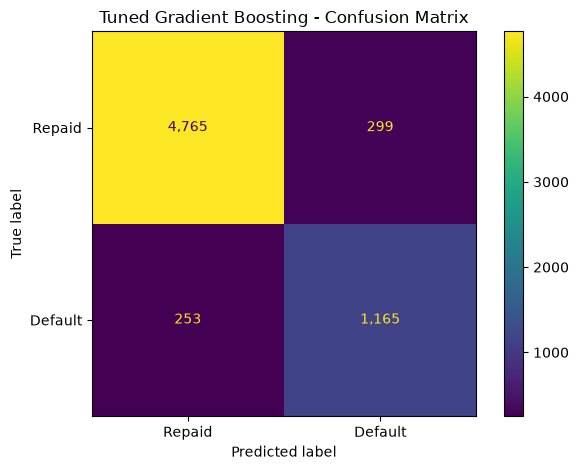

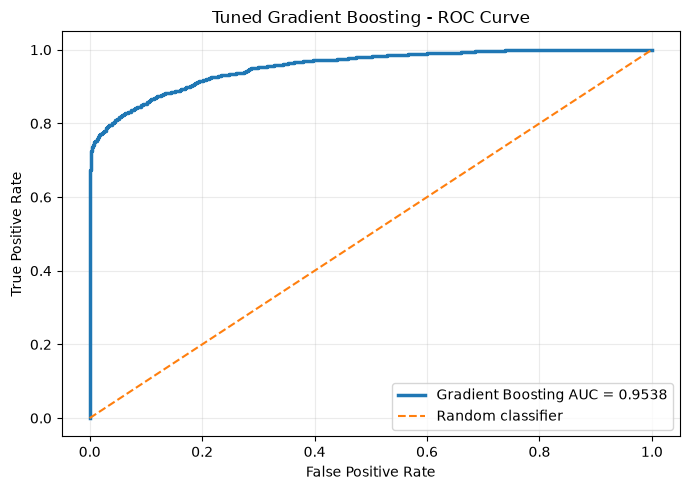

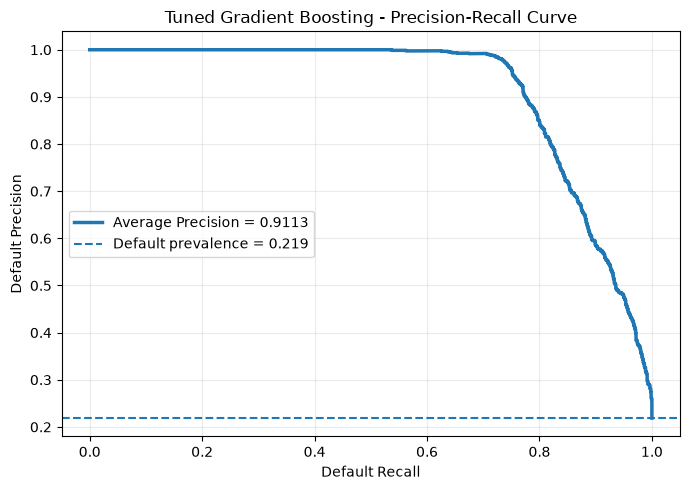

In [28]:
# 7. Evaluate the Tuned Gradient Boosting Model

best_gb = gradient_search.best_estimator_

tuned_results, tuned_probabilities, tuned_predictions = evaluate_classifier(
    model_name="Tuned Gradient Boosting",
    model=best_gb,
    X_eval=X_test_enc,
    y_eval=y_test,
    threshold=0.50
)

print("Tuned Gradient Boosting")
print("-" * 40)

for metric, value in tuned_results.items():
    if metric not in ["Model", "Threshold"]:
        print(f"{metric:<22}: {value:.4f}")

print("\nClassification Report")
print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=["Repaid", "Default"]
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=["Repaid", "Default"],
    values_format=",d"
)
plt.title("Tuned Gradient Boosting - Confusion Matrix")
plt.tight_layout()
plt.show()

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(7, 5))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2.5,
    label=f"Gradient Boosting AUC = {tuned_results['ROC AUC']:.4f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Gradient Boosting - ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(7, 5))
plt.plot(
    test_recall_curve,
    test_precision_curve,
    linewidth=2.5,
    label=(
        "Average Precision = "
        f"{tuned_results['Average Precision']:.4f}"
    )
)
plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Default prevalence = {y_test.mean():.3f}"
)
plt.xlabel("Default Recall")
plt.ylabel("Default Precision")
plt.title("Tuned Gradient Boosting - Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

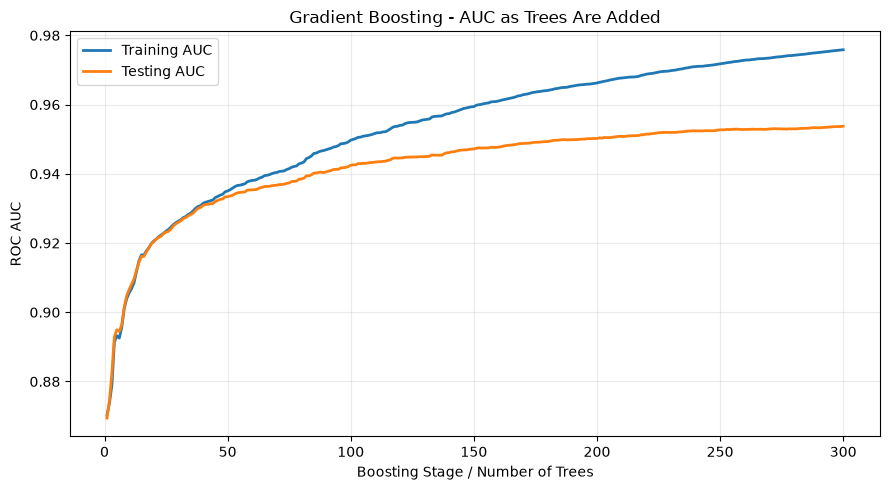

Model estimators: 300
Highest test AUC on the diagnostic curve: 0.9538 at stage 300
The test curve is displayed only as an overfitting diagnostic. The model was selected using cross-validation, not this test curve.


In [29]:
# 8. Examine Performance After Each Boosting Stage

train_auc_by_stage = []
test_auc_by_stage = []

for train_stage_probabilities, test_stage_probabilities in zip(
    best_gb.staged_predict_proba(X_train_enc),
    best_gb.staged_predict_proba(X_test_enc)
):
    train_auc_by_stage.append(
        roc_auc_score(y_train, train_stage_probabilities[:, 1])
    )

    test_auc_by_stage.append(
        roc_auc_score(y_test, test_stage_probabilities[:, 1])
    )

stages = np.arange(1, len(train_auc_by_stage) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    stages,
    train_auc_by_stage,
    linewidth=2,
    label="Training AUC"
)
plt.plot(
    stages,
    test_auc_by_stage,
    linewidth=2,
    label="Testing AUC"
)
plt.xlabel("Boosting Stage / Number of Trees")
plt.ylabel("ROC AUC")
plt.title("Gradient Boosting - AUC as Trees Are Added")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

highest_diagnostic_stage = int(np.argmax(test_auc_by_stage) + 1)
highest_diagnostic_auc = max(test_auc_by_stage)

print(f"Model estimators: {best_gb.n_estimators_}")
print(
    "Highest test AUC on the diagnostic curve:",
    f"{highest_diagnostic_auc:.4f} at stage {highest_diagnostic_stage}"
)
print(
    "The test curve is displayed only as an overfitting diagnostic. "
    "The model was selected using cross-validation, not this test curve."
)

Validation-selected threshold: 0.6336
Validation F1 at selected threshold: 0.8243

Threshold Comparison
                                         Model  Threshold  Accuracy  Balanced Accuracy  Default Precision  Default Recall  Default F1
                       Tuned Gradient Boosting     0.5000    0.9148             0.8813             0.7958          0.8216      0.8085
Tuned Gradient Boosting - Validation Threshold     0.6336    0.9320             0.8747             0.9021          0.7729      0.8325

Classification Report at Validation-Selected Threshold
              precision    recall  f1-score   support

      Repaid       0.94      0.98      0.96      5064
     Default       0.90      0.77      0.83      1418

    accuracy                           0.93      6482
   macro avg       0.92      0.87      0.89      6482
weighted avg       0.93      0.93      0.93      6482



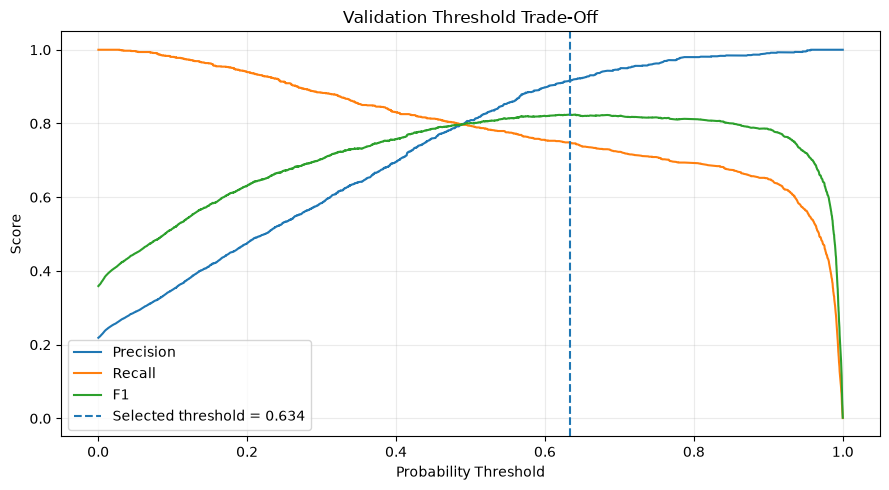

In [30]:
# 9. Select a Classification Threshold Using Training Validation Data

y_train_array = np.asarray(y_train)
all_training_indices = np.arange(len(y_train_array))

threshold_fit_indices, threshold_validation_indices = train_test_split(
    all_training_indices,
    test_size=0.20,
    random_state=42,
    stratify=y_train_array
)

threshold_model = clone(best_gb)

threshold_fit_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_array[threshold_fit_indices]
)

threshold_model.fit(
    X_train_enc[threshold_fit_indices],
    y_train_array[threshold_fit_indices],
    sample_weight=threshold_fit_weights
)

validation_probabilities = threshold_model.predict_proba(
    X_train_enc[threshold_validation_indices]
)[:, 1]

validation_precision, validation_recall, validation_thresholds = (
    precision_recall_curve(
        y_train_array[threshold_validation_indices],
        validation_probabilities
    )
)

validation_f1 = (
    2
    * validation_precision[:-1]
    * validation_recall[:-1]
    / (
        validation_precision[:-1]
        + validation_recall[:-1]
        + 1e-12
    )
)

best_threshold_index = int(np.nanargmax(validation_f1))
selected_threshold = float(
    validation_thresholds[best_threshold_index]
)

print(f"Validation-selected threshold: {selected_threshold:.4f}")
print(
    "Validation F1 at selected threshold:",
    f"{validation_f1[best_threshold_index]:.4f}"
)

threshold_results, _, threshold_predictions = evaluate_classifier(
    model_name="Tuned Gradient Boosting - Validation Threshold",
    model=best_gb,
    X_eval=X_test_enc,
    y_eval=y_test,
    threshold=selected_threshold
)

threshold_comparison = pd.DataFrame(
    [tuned_results, threshold_results]
)

print("\nThreshold Comparison")
print(
    threshold_comparison[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Balanced Accuracy",
            "Default Precision",
            "Default Recall",
            "Default F1"
        ]
    ].round(4).to_string(index=False)
)

print("\nClassification Report at Validation-Selected Threshold")
print(
    classification_report(
        y_test,
        threshold_predictions,
        target_names=["Repaid", "Default"]
    )
)

plt.figure(figsize=(9, 5))
plt.plot(
    validation_thresholds,
    validation_precision[:-1],
    label="Precision"
)
plt.plot(
    validation_thresholds,
    validation_recall[:-1],
    label="Recall"
)
plt.plot(
    validation_thresholds,
    validation_f1,
    label="F1"
)
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.3f}"
)
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Trade-Off")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Top Impurity-Based Features
                       Feature  Impurity Importance
                 loan_int_rate              0.27884
           loan_percent_income              0.25434
                 person_income              0.21134
    person_home_ownership_RENT              0.05526
                  loan_grade_C              0.03700
     person_home_ownership_OWN              0.02505
             person_emp_length              0.02044
                  loan_grade_D              0.01675
                     loan_amnt              0.01493
   loan_intent_HOMEIMPROVEMENT              0.01474
                    person_age              0.01447
           loan_intent_MEDICAL              0.01261
           loan_intent_VENTURE              0.01255
 loan_intent_DEBTCONSOLIDATION              0.01110
person_home_ownership_MORTGAGE              0.00546


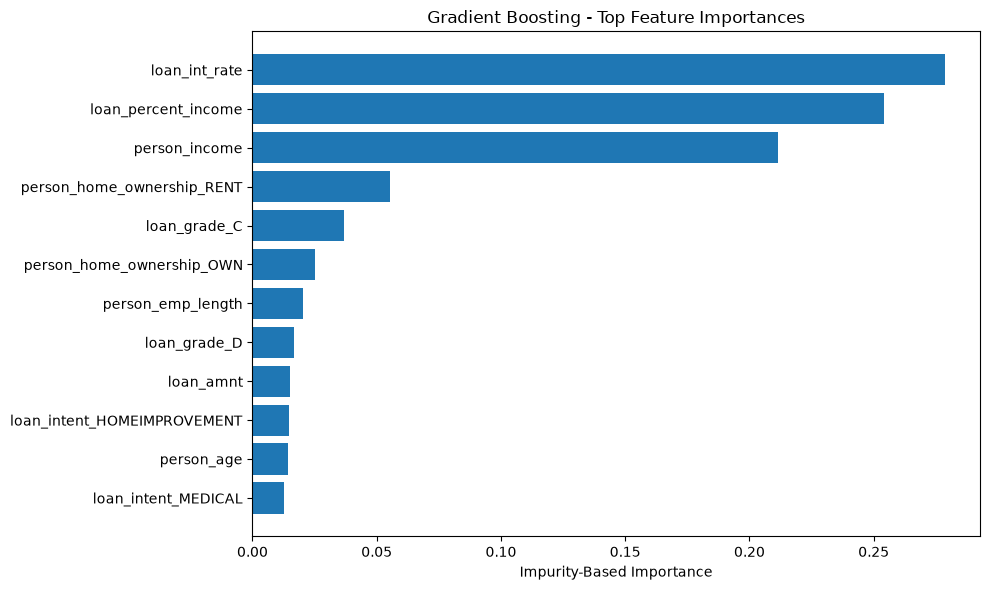

In [31]:
# 10. Impurity-Based Feature Importance

impurity_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Impurity Importance": best_gb.feature_importances_
}).sort_values(
    "Impurity Importance",
    ascending=False
)

print("Top Impurity-Based Features")
print(
    impurity_importance_df.head(15)
    .round(5)
    .to_string(index=False)
)

top_impurity = (
    impurity_importance_df
    .head(12)
    .sort_values("Impurity Importance")
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_impurity["Feature"],
    top_impurity["Impurity Importance"]
)
plt.xlabel("Impurity-Based Importance")
plt.title("Gradient Boosting - Top Feature Importances")
plt.tight_layout()
plt.show()

Top Permutation-Importance Features
                       Feature  Permutation Importance  Importance Std
                 person_income                 0.10548         0.00222
           loan_percent_income                 0.08885         0.00123
                 loan_int_rate                 0.05520         0.00121
     person_home_ownership_OWN                 0.02775         0.00186
    person_home_ownership_RENT                 0.01675         0.00146
           loan_intent_VENTURE                 0.01376         0.00296
                     loan_amnt                 0.00916         0.00163
   loan_intent_HOMEIMPROVEMENT                 0.00870         0.00022
                  loan_grade_D                 0.00712         0.00092
                    person_age                 0.00675         0.00062
             person_emp_length                 0.00528         0.00076
           loan_intent_MEDICAL                 0.00419         0.00025
 loan_intent_DEBTCONSOLIDATION           

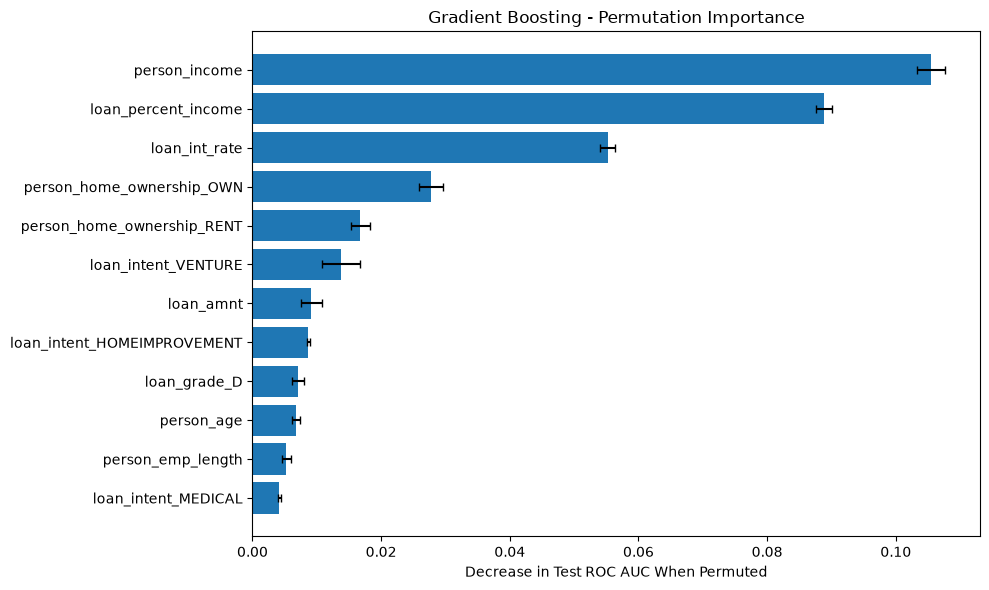


Importance Comparison
                       Feature  Impurity Importance  Permutation Importance  Importance Std
                 person_income              0.21134                 0.10548         0.00222
           loan_percent_income              0.25434                 0.08885         0.00123
                 loan_int_rate              0.27884                 0.05520         0.00121
     person_home_ownership_OWN              0.02505                 0.02775         0.00186
    person_home_ownership_RENT              0.05526                 0.01675         0.00146
           loan_intent_VENTURE              0.01255                 0.01376         0.00296
                     loan_amnt              0.01493                 0.00916         0.00163
   loan_intent_HOMEIMPROVEMENT              0.01474                 0.00870         0.00022
                  loan_grade_D              0.01675                 0.00712         0.00092
                    person_age              0.01447      

In [32]:
# 11. Permutation Importance on the Held-Out Test Set

permutation_results = permutation_importance(
    estimator=best_gb,
    X=X_test_enc,
    y=y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Permutation Importance": permutation_results.importances_mean,
    "Importance Std": permutation_results.importances_std
}).sort_values(
    "Permutation Importance",
    ascending=False
)

print("Top Permutation-Importance Features")
print(
    permutation_importance_df.head(15)
    .round(5)
    .to_string(index=False)
)

top_permutation = (
    permutation_importance_df
    .head(12)
    .sort_values("Permutation Importance")
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_permutation["Feature"],
    top_permutation["Permutation Importance"],
    xerr=top_permutation["Importance Std"],
    capsize=3
)
plt.xlabel("Decrease in Test ROC AUC When Permuted")
plt.title("Gradient Boosting - Permutation Importance")
plt.tight_layout()
plt.show()

importance_comparison = (
    impurity_importance_df
    .merge(
        permutation_importance_df,
        on="Feature",
        how="inner"
    )
    .sort_values(
        "Permutation Importance",
        ascending=False
    )
)

print("\nImportance Comparison")
print(
    importance_comparison.head(15)
    .round(5)
    .to_string(index=False)
)

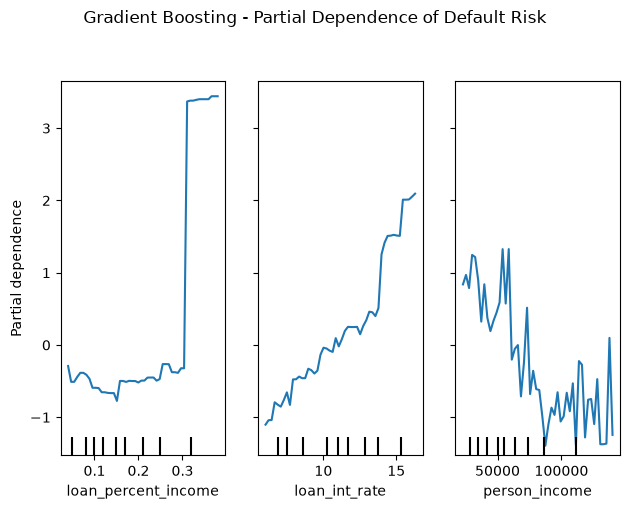

In [33]:
# 12. Partial Dependence for Important Continuous Variables

partial_dependence_features = [
    "loan_percent_income",
    "loan_int_rate",
    "person_income"
]

partial_dependence_indices = [
    feature_names.index(feature)
    for feature in partial_dependence_features
]

# A sample reduces plotting time without changing the fitted model
random_generator = np.random.default_rng(42)

partial_dependence_sample_indices = random_generator.choice(
    len(X_test_enc),
    size=min(3000, len(X_test_enc)),
    replace=False
)

X_partial_dependence = X_test_enc[
    partial_dependence_sample_indices
]

PartialDependenceDisplay.from_estimator(
    estimator=best_gb,
    X=X_partial_dependence,
    features=partial_dependence_indices,
    feature_names=feature_names,
    kind="average",
    grid_resolution=50
)

plt.suptitle(
    "Gradient Boosting - Partial Dependence of Default Risk",
    y=1.05
)
plt.tight_layout()
plt.show()

In [ ]:

#13.Rebuild the Week 6 Random Forest Benchmark

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

random_forest.fit(
    X_train_enc,
    y_train
)

rf_results, rf_probabilities, rf_predictions = evaluate_classifier(
    model_name="Random Forest - Week 6 Specification",
    model=random_forest,
    X_eval=X_test_enc,
    y_eval=y_test,
    threshold=0.50
)

print("Random Forest Benchmark")
print("-" * 40)

for metric, value in rf_results.items():
    if metric not in ["Model", "Threshold"]:
        print(f"{metric:<22}: {value:.4f}")

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Repaid", "Default"]
    )
)

Random Forest Benchmark
----------------------------------------
Accuracy              : 0.9185
Balanced Accuracy     : 0.8659
ROC AUC               : 0.9345
Average Precision     : 0.8875
Default Precision     : 0.8423
Default Recall        : 0.7722
Default F1            : 0.8057

Classification Report
              precision    recall  f1-score   support

      Repaid       0.94      0.96      0.95      5064
     Default       0.84      0.77      0.81      1418

    accuracy                           0.92      6482
   macro avg       0.89      0.87      0.88      6482
weighted avg       0.92      0.92      0.92      6482



Week 9 Model Leaderboard
                               Model  ROC AUC  Average Precision  Accuracy  Balanced Accuracy  Default Precision  Default Recall  Default F1
             Tuned Gradient Boosting   0.9538             0.9113    0.9148             0.8813             0.7958          0.8216      0.8085
Random Forest - Week 6 Specification   0.9345             0.8875    0.9185             0.8659             0.8423          0.7722      0.8057
          Baseline Gradient Boosting   0.9323             0.8779    0.8854             0.8530             0.7135          0.7955      0.7523


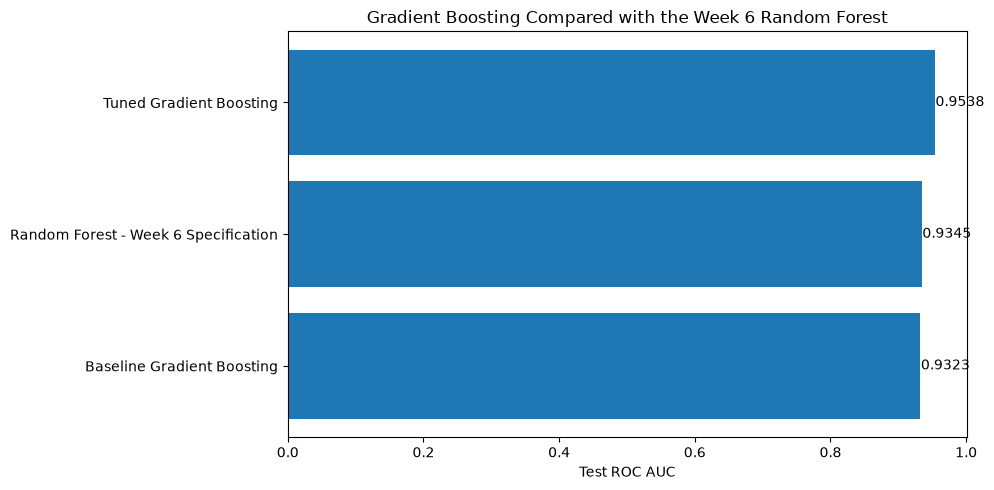

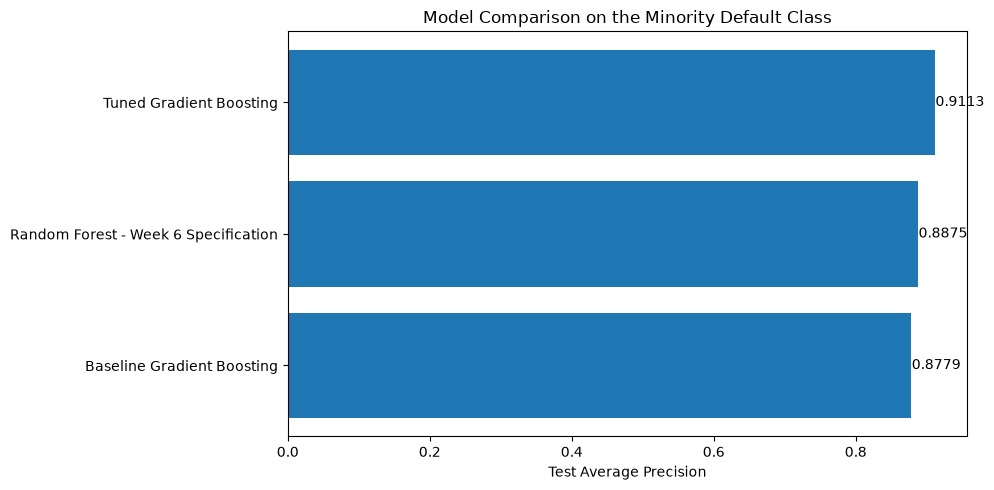


Highest test AUC: Tuned Gradient Boosting (0.9538)
Tuned Gradient Boosting minus Random Forest AUC: +0.0193
[Inference] Gradient boosting provides a meaningful improvement in borrower-risk ranking on this test set.

[Inference] The threshold comparison shows how the same probability model can produce different lending outcomes depending on the desired balance between catching defaults and incorrectly flagging borrowers who would repay.


In [35]:
# 14. Final Week 9 Model Comparison

model_comparison = pd.DataFrame([
    baseline_results,
    tuned_results,
    rf_results
]).sort_values(
    "ROC AUC",
    ascending=False
).reset_index(drop=True)

comparison_columns = [
    "Model",
    "ROC AUC",
    "Average Precision",
    "Accuracy",
    "Balanced Accuracy",
    "Default Precision",
    "Default Recall",
    "Default F1"
]

print("Week 9 Model Leaderboard")
print(
    model_comparison[comparison_columns]
    .round(4)
    .to_string(index=False)
)

auc_order = model_comparison.sort_values("ROC AUC")

plt.figure(figsize=(10, 5))
plt.barh(
    auc_order["Model"],
    auc_order["ROC AUC"]
)

for index, value in enumerate(auc_order["ROC AUC"]):
    plt.text(
        value + 0.001,
        index,
        f"{value:.4f}",
        va="center"
    )

plt.xlabel("Test ROC AUC")
plt.title("Gradient Boosting Compared with the Week 6 Random Forest")
plt.tight_layout()
plt.show()

ap_order = model_comparison.sort_values("Average Precision")

plt.figure(figsize=(10, 5))
plt.barh(
    ap_order["Model"],
    ap_order["Average Precision"]
)

for index, value in enumerate(ap_order["Average Precision"]):
    plt.text(
        value + 0.001,
        index,
        f"{value:.4f}",
        va="center"
    )

plt.xlabel("Test Average Precision")
plt.title("Model Comparison on the Minority Default Class")
plt.tight_layout()
plt.show()

best_auc_model = model_comparison.iloc[0]

gb_rf_auc_difference = (
    tuned_results["ROC AUC"]
    - rf_results["ROC AUC"]
)

print(
    f"\nHighest test AUC: {best_auc_model['Model']} "
    f"({best_auc_model['ROC AUC']:.4f})"
)

print(
    "Tuned Gradient Boosting minus Random Forest AUC:",
    f"{gb_rf_auc_difference:+.4f}"
)

if gb_rf_auc_difference > 0.002:
    print(
        "[Inference] Gradient boosting provides a meaningful improvement "
        "in borrower-risk ranking on this test set."
    )
elif gb_rf_auc_difference < -0.002:
    print(
        "[Inference] The random forest remains the stronger risk-ranking "
        "model on this test set."
    )
else:
    print(
        "[Inference] Gradient boosting and random forest perform nearly "
        "identically, so runtime, stability, and interpretability become "
        "more important selection criteria."
    )

print(
    "\n[Inference] The threshold comparison shows how the same probability "
    "model can produce different lending outcomes depending on the desired "
    "balance between catching defaults and incorrectly flagging borrowers "
    "who would repay."
)